# Prac 06.2 
#### Порівняння трекерів KCF і CSRT

### Step 0. Імпорт бібліотек

In [20]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

plt.rcParams['figure.figsize'] = [15, 9]

### Step 1. Завантаження відео та вибір об'єкта
Для трекінгу вибрано людину, яка йде стежкою. Початкову рамку задаємо на 30-му кадрі.

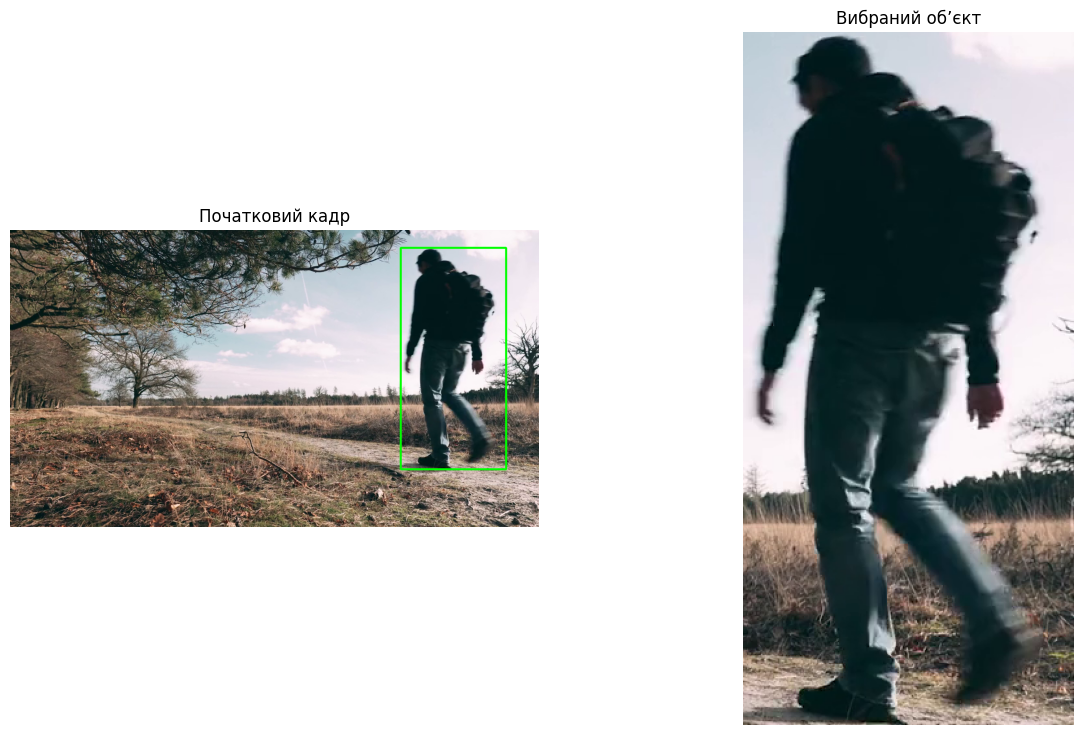

In [21]:
video_path = 'walking_video.mp4'
start_frame = 30
number_of_frames = 15
initial_bbox = (945, 45, 255, 535)

video = cv2.VideoCapture(video_path)
video.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
success, first_frame = video.read()
video.release()

if not success:
    raise RuntimeError('Не вдалося відкрити відео')

x, y, w, h = initial_bbox
template = first_frame[y:y+h, x:x+w]
first_frame_with_box = np.copy(first_frame)
cv2.rectangle(first_frame_with_box, (x, y), (x+w, y+h), (0, 255, 0), 4)

plt.subplot(121)
plt.imshow(cv2.cvtColor(first_frame_with_box, cv2.COLOR_BGR2RGB))
plt.title('Початковий кадр')
plt.axis('off')

plt.subplot(122)
plt.imshow(cv2.cvtColor(template, cv2.COLOR_BGR2RGB))
plt.title('Вибраний об’єкт')
plt.axis('off')
plt.show()

### Функції для трекінгу та виведення результатів

In [22]:
def track_object(tracker_name):
    video = cv2.VideoCapture(video_path)
    video.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
    success, frame = video.read()

    if tracker_name == 'KCF':
        if hasattr(cv2, 'TrackerKCF_create'):
            tracker = cv2.TrackerKCF_create()
        else:
             tracker = cv2.legacy.TrackerKCF_create()
    else:
        if hasattr(cv2, 'TrackerCSRT_create'):
            tracker = cv2.TrackerCSRT_create()
        else:
            tracker = cv2.legacy.TrackerCSRT_create()

    tracker.init(frame, initial_bbox)
    result_frames = []

    for i in range(number_of_frames):
        if i == 0:
            found = True
            bbox = initial_bbox
        else:
            success, frame = video.read()
            if not success:
                break
            found, bbox = tracker.update(frame)

        result = np.copy(frame)

        if found:
            x, y, w, h = map(int, bbox)
            cv2.rectangle(result, (x, y), (x+w, y+h), (0, 255, 0), 4)
        else:
            cv2.putText(result, 'Object lost', (40, 60),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 0, 0), 3)

        cv2.putText(result, tracker_name + ': frame ' + str(i+1),
                    (30, 50), cv2.FONT_HERSHEY_SIMPLEX,
                    1.2, (0, 255, 0), 3)

        result_frames.append(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))

    video.release()
    return result_frames


def show_results(frames, title):
    fig, axes = plt.subplots(3, 5, figsize=(18, 10))
    for i, ax in enumerate(axes.ravel()):
        ax.imshow(frames[i])
        ax.set_title('Кадр ' + str(i+1))
        ax.axis('off')
    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

### Step 2–4. Трекінг за допомогою KCF

In [23]:
# %pip uninstall -y opencv-python opencv-python-headless opencv-contrib-python opencv-contrib-python-headless
# %pip install opencv-contrib-python

Збережено кадрів: 15


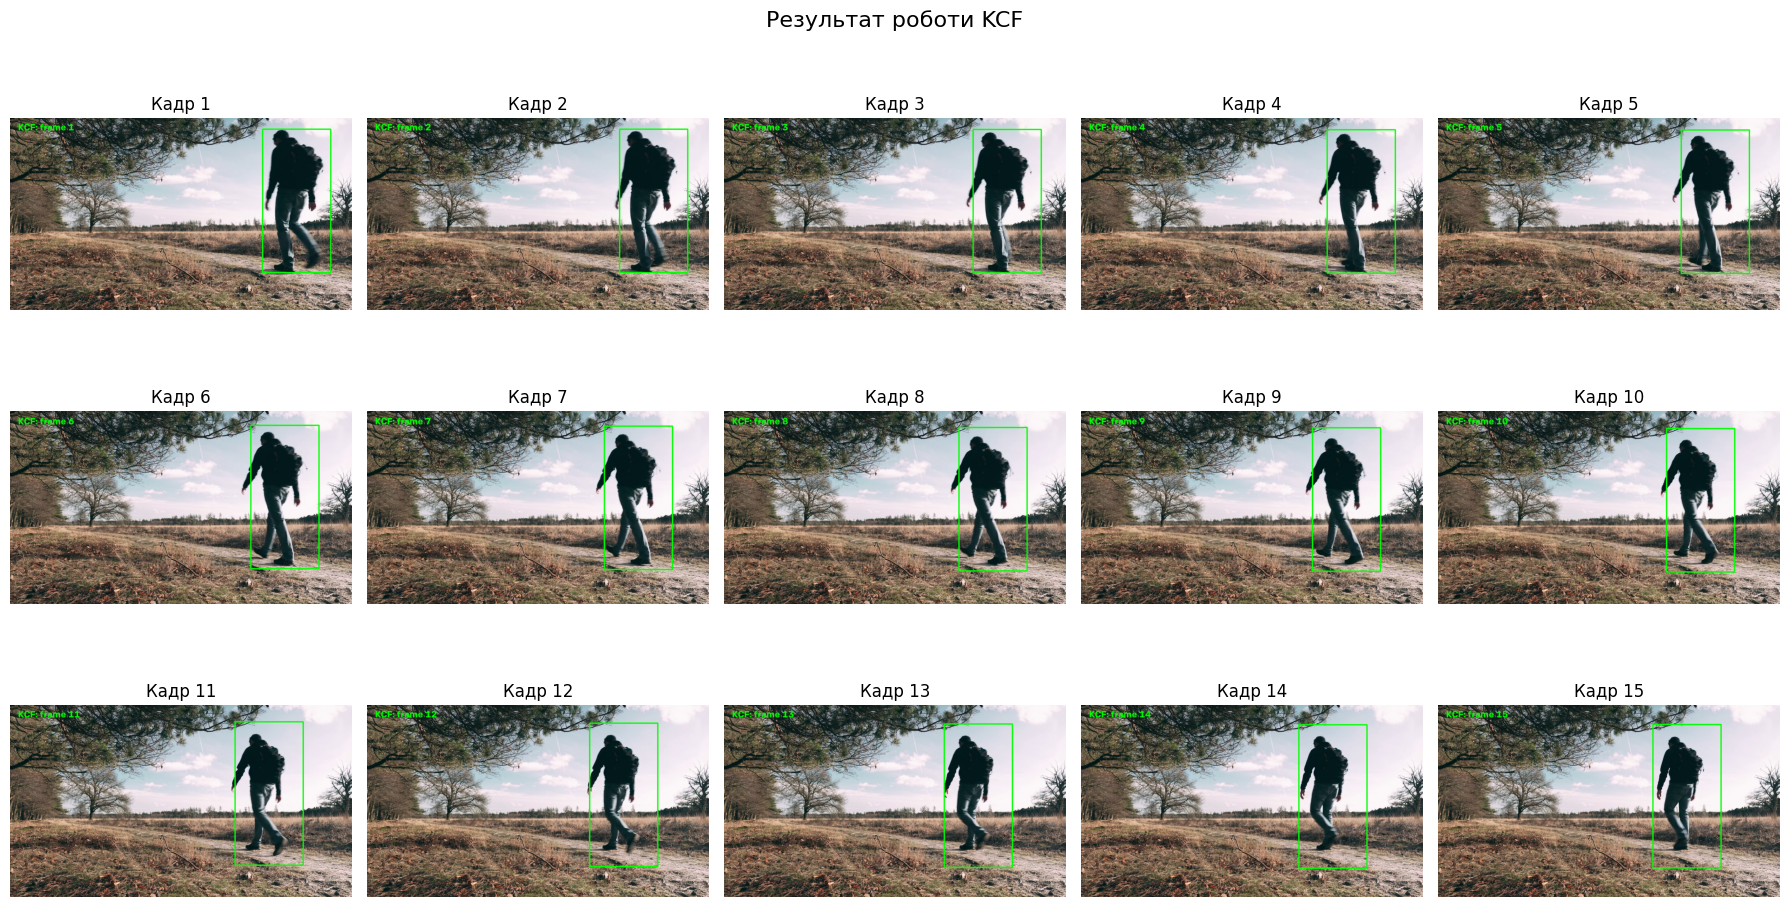

In [24]:
kcf_frames = track_object('KCF')
print('Збережено кадрів:', len(kcf_frames))
show_results(kcf_frames, 'Результат роботи KCF')

### Step 5. Трекінг за допомогою CSRT

Збережено кадрів: 15


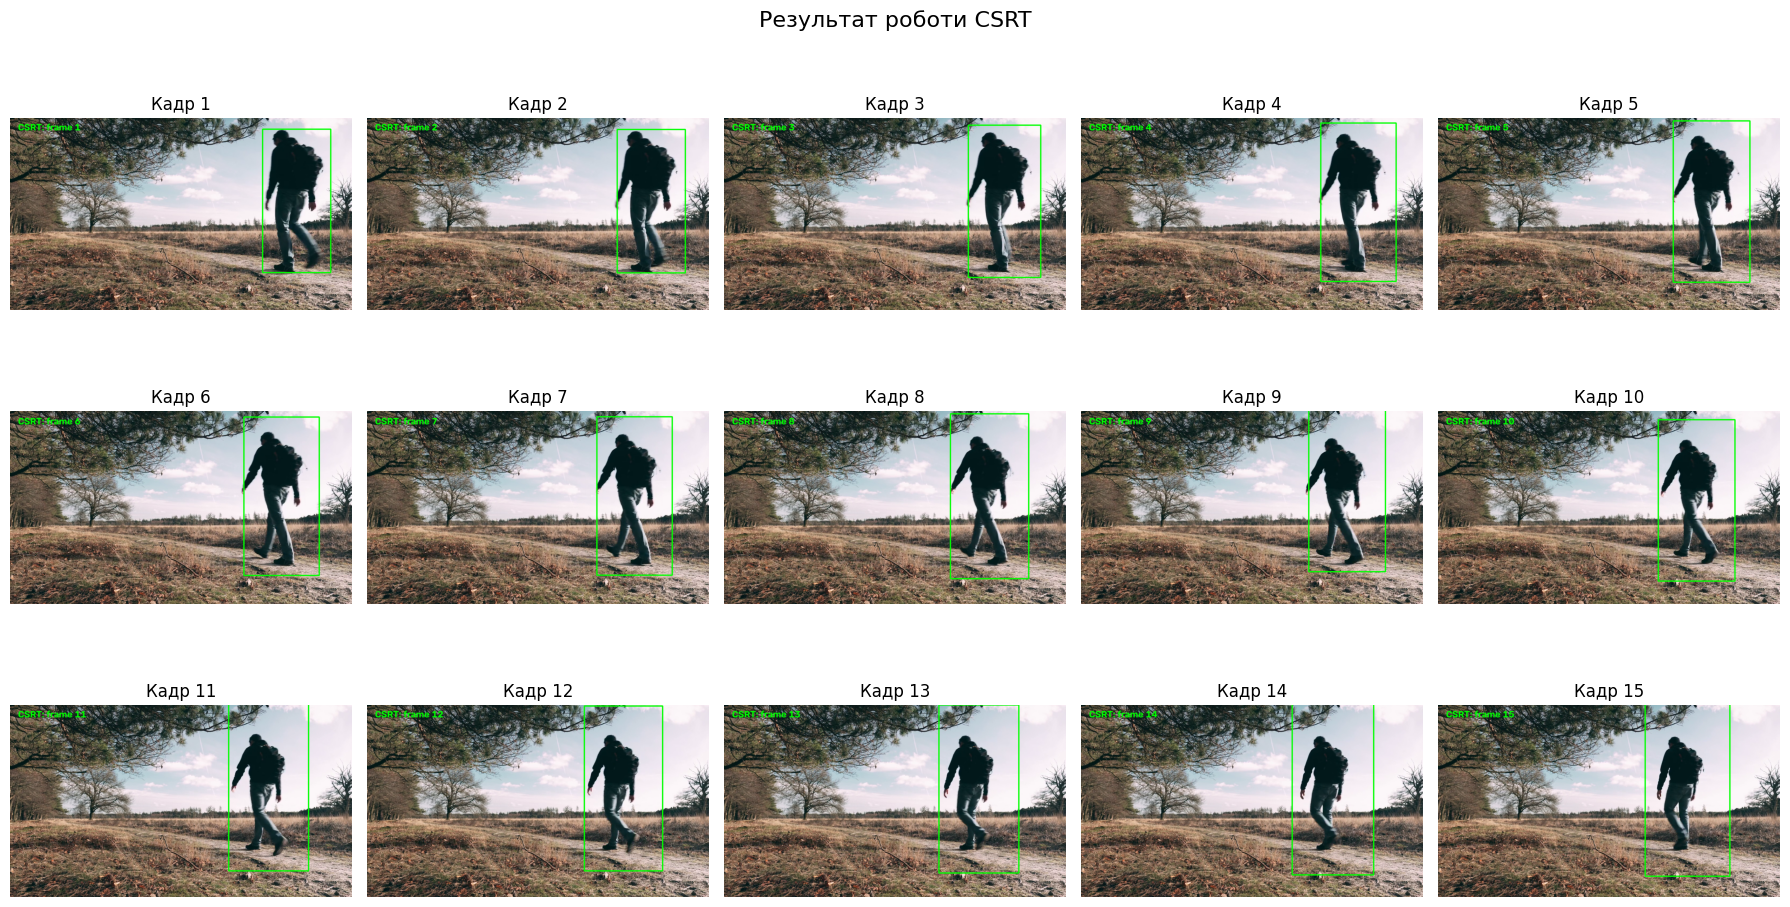

In [25]:
csrt_frames = track_object('CSRT')
print('Збережено кадрів:', len(csrt_frames))
show_results(csrt_frames, 'Результат роботи CSRT')